# <span style="color:black; font-weight:bold;">MAPS-integration-P multi-omics prediction Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com) and Zhikang Wang
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 8.29.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 8.29.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Train slices data used in the tutorial are available at [hbc313_uni2_cls_rep1.h5ad](https://drive.google.com/file/d/1s4Ryvh_Zo8xf4cW2DyzivKflxFBv_kI0/view?usp=sharing), [hbc313_uni2_cls_rep1_protein.h5ad](https://drive.google.com/file/d/1Preje_IHlg1OyalnsPAMpO5Tn5LR0C9A/view?usp=sharing), test slice is is available at [hbc313_uni2_cls_rep2.h5ad](https://drive.google.com/file/d/1z_hREmofrnnbs2P2DSCGEr02Auke_5tO/view?usp=sharing)
In this tutorial we apply MAPS-integration-P to predict multi-omics 

In [1]:
import argparse
import datetime
import os
import os.path as osp
import random
import sys
import time
import anndata as ad

import numpy as np
import scanpy as sc
import torch
import torch.nn as nn
from torch.optim import lr_scheduler
from MAPS.utils import set_seed
from MAPS.integration_P.datasets.datasets import Single_omics, Multi_omics
from MAPS.integration_P.model.network import Network_single_omics, Network_multi_omics, init_weights
from MAPS.integration_P.utils.utils import Logger
from MAPS.integration_P.utils.utils_dataloader import dataloader_single, dataloader_multi
from MAPS.integration_P.utils.utils_training import train_multi_omics, test_multi_omics, train_single_omics, test_single_omics

## <span style="color:black; font-weight:bold;">Set the training data path and training parameters</span>

In [2]:
parser = argparse.ArgumentParser(description='Multi-omics translation')

################
# for model
parser.add_argument('--noise_rate', default=0.2, type=float)
parser.add_argument('--dropout_rate', default=0.1, type=float)

# Datasets
parser.add_argument('--path_omics', type=str, default='/home/dbj/LPcross/Data/zhikang/tutorial',
                    help='path to the omics data (h5ad files)')
parser.add_argument('--train_slices', type=str, default={'omics1': ['hbc313_uni2_cls_rep1.h5ad'], 'omics2': ['hbc313_uni2_cls_rep1_protein.h5ad']})
parser.add_argument('--test_slices', type=str, default=['hbc313_uni2_cls_rep2.h5ad'])


# Training options
parser.add_argument('--workers', default=16, type=int)
parser.add_argument('--max-epoch', default=15, type=int)
parser.add_argument('--stepsize', default=5, type=int)

parser.add_argument('--train-batch', default=2048, type=int)
parser.add_argument('--test-batch', default=2048, type=int) 

# Optimization options
parser.add_argument('--optimizer', default='adam', type=str,
                    help="adam or SGD")
parser.add_argument('--lr', '--learning-rate', default=0.001, type=float,
                    help="initial learning rate, use 0.0001")
parser.add_argument('--gamma', default=0.1, type=float,
                    help="learning rate decay")
parser.add_argument('--weight-decay', default=5e-04, type=float,
                    help="weight decay (default: 5e-04)")

# Miscs
parser.add_argument('--seed', type=int, default=1, 
                    help="manual seed")
parser.add_argument('--eval-step', type=int, default=15, #
                    help="run evaluation for every N epochs (set to -1 to test after training)")

_StoreAction(option_strings=['--eval-step'], dest='eval_step', nargs=None, const=None, default=15, type=<class 'int'>, choices=None, required=False, help='run evaluation for every N epochs (set to -1 to test after training)', metavar=None)

## <span style="color:black; font-weight:bold;">Set up the training device</span>

In [3]:
parser.add_argument('--gpu-devices', default='0', type=str, 
                    help='gpu device ids for CUDA_VISIBLE_DEVICES')
args = parser.parse_args(args=[])

In [4]:
set_seed(args.seed)
os.environ['CUDA_VISIBLE_DEVICES'] = args.gpu_devices

print("==========\nArgs:{}\n==========".format(args))

Args:Namespace(noise_rate=0.2, dropout_rate=0.1, path_omics='/home/dbj/LPcross/Data/zhikang/tutorial', train_slices={'omics1': ['hbc313_uni2_cls_rep1.h5ad'], 'omics2': ['hbc313_uni2_cls_rep1_protein.h5ad']}, test_slices=['hbc313_uni2_cls_rep2.h5ad'], workers=16, max_epoch=15, stepsize=5, train_batch=2048, test_batch=2048, optimizer='adam', lr=0.001, gamma=0.1, weight_decay=0.0005, seed=1, eval_step=15, gpu_devices='0')


## <span style="color:black; font-weight:bold;">Building the single-omics training data</span>

In [5]:
dataset = Multi_omics(path_omics = args.path_omics, train_slices=args.train_slices, test_slices=args.test_slices)
trainloader, testloader = dataloader_multi(args, dataset)

=> Liver cancer loaded
Dataset statistics:
  ------------------------------
  Panel    |  Omics1:313 Omics2:2| 
  ------------------------------
  train    |  167780 cells from     2 slides 
  test     |  111921 cells from     1 slides
  ------------------------------


## <span style="color:black; font-weight:bold;">Model initialization</span>

In [6]:
model = Network_multi_omics(omics1_size=dataset.panel_size_omics1, 
                            omics2_size=dataset.panel_size_omics2,
                            input_dimension=dataset.fea_size,
                            noise_rate=args.noise_rate, 
                            dropout_rate=args.dropout_rate)

model.apply(init_weights)
model = nn.DataParallel(model).cuda()

In [7]:
criterion_mse, criterion_ce = nn.MSELoss(), nn.CrossEntropyLoss()

if args.optimizer == 'adam':
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
elif args.optimizer == 'SGD':
    optimizer = torch.optim.SGD(model.parameters(), lr=args.lr)
else:
    print('unexpected optimizer')

if args.stepsize > 0:
    scheduler = lr_scheduler.StepLR(optimizer, step_size=args.stepsize, gamma=args.gamma)

## <span style="color:black; font-weight:bold;">Training process</span>

In [8]:
start_time = time.time()

for epoch in range(args.max_epoch):
    ################
    print("==> Epoch {}/{}".format(epoch+1, args.max_epoch), flush=True)

    train_multi_omics(model, criterion_mse, criterion_ce, optimizer, trainloader)

    if args.stepsize > 0: scheduler.step()
    
    if (epoch+1) % args.eval_step == 0:
        print("==> Test", flush=True)
        pred_omics1, pred_omics2 = test_multi_omics(model, testloader, dataset.panel_omics1, dataset.panel_omics2 )
    ################

torch.save(model.state_dict(), 'last.pth')

elapsed = round(time.time() - start_time)
elapsed = str(datetime.timedelta(seconds=elapsed))
print("Finished. Total elapsed time (h:m:s): {}".format(elapsed))

==> Epoch 1/15
Batch 81/81	 Loss 14.705282 (32.783794)
==> Epoch 2/15
Batch 81/81	 Loss 13.729275 (14.060484)
==> Epoch 3/15
Batch 81/81	 Loss 13.200623 (13.445436)
==> Epoch 4/15
Batch 81/81	 Loss 13.020922 (13.094071)
==> Epoch 5/15
Batch 81/81	 Loss 13.008602 (12.844836)
==> Epoch 6/15
Batch 81/81	 Loss 12.420549 (12.658628)
==> Epoch 7/15
Batch 81/81	 Loss 12.463128 (12.616832)
==> Epoch 8/15
Batch 81/81	 Loss 12.542057 (12.596129)
==> Epoch 9/15
Batch 81/81	 Loss 12.548674 (12.573410)
==> Epoch 10/15
Batch 81/81	 Loss 13.037508 (12.555054)
==> Epoch 11/15
Batch 81/81	 Loss 12.804646 (12.540024)
==> Epoch 12/15
Batch 81/81	 Loss 12.579041 (12.540673)
==> Epoch 13/15
Batch 81/81	 Loss 12.414351 (12.528134)
==> Epoch 14/15
Batch 81/81	 Loss 12.349692 (12.526565)
==> Epoch 15/15
Batch 81/81	 Loss 12.563074 (12.523893)
==> Test
Finished. Total elapsed time (h:m:s): 0:02:09


## <span style="color:black; font-weight:bold;">Prediction results</span>

In [9]:
adata = ad.AnnData(X=np.exp(pred_omics2 * (dataset.max_omics2 - dataset.min_omics2) + dataset.min_omics2)-1)
adata.var_names = np.asarray(dataset.panel_omics2).astype(str)
adata.obsm["spatial"] = dataset.test_adata_spatial

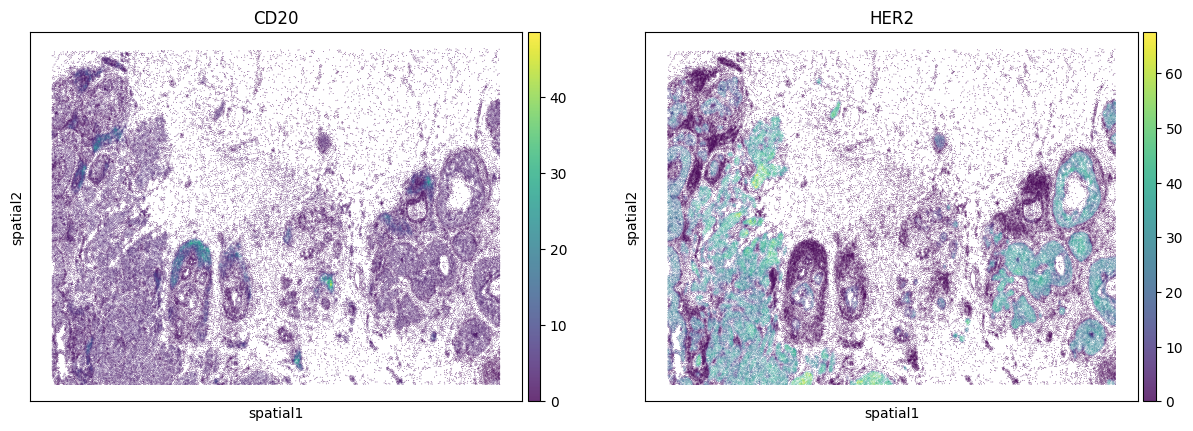

In [10]:
sc.pl.embedding(adata, basis="spatial", color=dataset.panel_omics2, size=1.5, alpha=0.8, ncols=4)